# 03_Simulaciones

Simulación de inversión con USD 10,000 durante el año 2025, usando el mejor modelo
entrenado para el activo principal (AAPL) a partir de `analytics.daily_features`.


In [2]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
from sqlalchemy import create_engine, text
import joblib
import matplotlib.pyplot as plt

# --- Parámetros de conexión Postgres desde env (mismos que en el resto del proyecto) ---
PG_HOST = os.getenv("PG_HOST", "postgres")
PG_PORT = os.getenv("PG_PORT", "5432")
PG_DB = os.getenv("PG_DB", "trading_db")
PG_USER = os.getenv("PG_USER", "trading_user")
PG_PASSWORD = os.getenv("PG_PASSWORD", "trading_pass")

PG_SCHEMA_ANALYTICS = os.getenv("PG_SCHEMA_ANALYTICS", "analytics")

print("Postgres:", PG_HOST, PG_PORT, PG_DB, PG_USER)

engine = create_engine(
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)

# Probar conexión rápida
with engine.connect() as conn:
    conn.execute(text("SELECT 1;"))
print("Conexión a Postgres OK ✅")

Postgres: postgres 5432 trading_db trading_user
Conexión a Postgres OK ✅


In [3]:
# Celda: construir features (lags) para un ticker, listo para ML/simulaciones

def build_features_for_ticker(ticker, engine):
    """
    Carga analytics.daily_features para un ticker,
    construye target_up y lags, y devuelve df_model + X + y.
    
    NO hace split temporal aquí; solo prepara todo.
    """

    print(f"\n=== Construyendo features para {ticker} (Simulación) ===")

    query = f"""
        SELECT *
        FROM {PG_SCHEMA_ANALYTICS}.daily_features
        WHERE ticker = :ticker
        ORDER BY date
    """

    df = pd.read_sql(text(query), engine, params={"ticker": ticker})
    df["date"] = pd.to_datetime(df["date"])

    print("Shape bruto:", df.shape)
    print("Rango fechas:", df["date"].min(), "→", df["date"].max())

    # Target (igual que en notebook de ML)
    df["target_up"] = (df["close"] > df["open"]).astype(int)

    # Lags
    lag_cols = [
        "open",
        "close",
        "high",
        "low",
        "volume",
        "return_close_open",
        "return_prev_close",
        "volatility_n_days",
    ]

    for col in lag_cols:
        df[f"{col}_lag1"] = df[col].shift(1)

    # Flags de calendario
    df["is_monday"] = df["day_of_week"] == 0
    df["is_friday"] = df["day_of_week"] == 4

    # Filtrar filas válidas (sin NaN en lags)
    lag_feature_cols = [
        "open_lag1",
        "close_lag1",
        "high_lag1",
        "low_lag1",
        "volume_lag1",
        "return_close_open_lag1",
        "return_prev_close_lag1",
        "volatility_n_days_lag1",
    ]

    mask_valid = df[lag_feature_cols].notnull().all(axis=1)
    df_model = df.loc[mask_valid].copy().reset_index(drop=True)

    print("Filas totales:", len(df))
    print("Filas válidas (con lags):", len(df_model))

    # Features (mismas que en el notebook de ML)
    feature_cols = [
        "day_of_week",
        "is_monday",
        "is_friday",
        "open_lag1",
        "close_lag1",
        "high_lag1",
        "low_lag1",
        "volume_lag1",
        "return_close_open_lag1",
        "return_prev_close_lag1",
        "volatility_n_days_lag1",
    ]

    X = df_model[feature_cols].copy()
    y = df_model["target_up"].copy()

    # Convertir bool a int
    X["is_monday"] = X["is_monday"].astype(int)
    X["is_friday"] = X["is_friday"].astype(int)

    return df_model, X, y, feature_cols

In [4]:
# Celda: cargar modelo ganador para AAPL y preparar datos de 2025

TICKER_MAIN = "AAPL"
MODELS_DIR = Path("models")
MODEL_PATH_AAPL = MODELS_DIR / "best_model_AAPL.pkl"

print("Cargando modelo desde:", MODEL_PATH_AAPL)
best_model_aapl = joblib.load(MODEL_PATH_AAPL)
print("Modelo cargado ✅")

# Construir features para todo el histórico de AAPL
df_model_aapl, X_aapl, y_aapl, feature_cols = build_features_for_ticker(TICKER_MAIN, engine)

# Filtrar solo 2025 (para simulación)
mask_2025 = (df_model_aapl["date"] >= "2025-01-01") & (df_model_aapl["date"] <= "2025-12-31")
df_2025 = df_model_aapl.loc[mask_2025].copy()
X_2025 = X_aapl.loc[mask_2025].copy()

print("\nDatos disponibles para 2025:")
print("Filas df_2025:", len(df_2025))
if len(df_2025) > 0:
    print("Rango fechas 2025:", df_2025["date"].min(), "→", df_2025["date"].max())
else:
    print("⚠️ No hay filas en 2025. Revisa la ingesta / feature-builder.")

Cargando modelo desde: models/best_model_AAPL.pkl
Modelo cargado ✅

=== Construyendo features para AAPL (Simulación) ===
Shape bruto: (1988, 17)
Rango fechas: 2018-01-02 00:00:00 → 2025-11-26 00:00:00
Filas totales: 1988
Filas válidas (con lags): 1977

Datos disponibles para 2025:
Filas df_2025: 227
Rango fechas 2025: 2025-01-02 00:00:00 → 2025-11-26 00:00:00


In [5]:
# Celda: funciones de simulación

def simulate_intraday_strategy(df_sim, preds, capital_inicial=10_000.0):
    """
    Regla sugerida en el enunciado:
    - Si prediction = 1: entras largo intradía (compras al open, vendes al close).
    - Si prediction = 0: te quedas en efectivo.

    df_sim: DataFrame que tiene columnas 'date', 'open', 'close'.
    preds: array o serie con 0/1 del mismo largo que df_sim.
    """

    capital = float(capital_inicial)
    equity_curve = []
    n_trades = 0

    for (idx, row), pred in zip(df_sim.iterrows(), preds):
        date = row["date"]
        open_price = row["open"]
        close_price = row["close"]

        if pred == 1:
            # Entras largo con TODO el capital disponible
            shares = capital / open_price
            capital = shares * close_price
            n_trades += 1
        else:
            # Te quedas en cash, el capital no cambia
            pass

        equity_curve.append(
            {
                "date": date,
                "capital": capital,
                "signal": int(pred),
                "open": open_price,
                "close": close_price,
            }
        )

    equity_df = pd.DataFrame(equity_curve).sort_values("date")

    capital_final = capital
    retorno_total = capital_final / capital_inicial - 1.0
    # Como es 1 año, retorno anualizado = retorno_total (podrías anualizar más formalmente si fuera multi-año)
    retorno_anualizado = retorno_total

    return {
        "equity_df": equity_df,
        "capital_final": capital_final,
        "retorno_total": retorno_total,
        "retorno_anualizado": retorno_anualizado,
        "n_trades": n_trades,
    }


def simulate_buy_and_hold(df_sim, capital_inicial=10_000.0):
    """
    Estrategia baseline: comprar al open del primer día y mantener hasta el último close.
    """

    df_sim = df_sim.sort_values("date").copy()
    first_open = df_sim.iloc[0]["open"]
    shares = capital_inicial / first_open

    equity_df = df_sim[["date", "close"]].copy()
    equity_df["capital"] = shares * equity_df["close"]

    capital_final = equity_df["capital"].iloc[-1]
    retorno_total = capital_final / capital_inicial - 1.0
    retorno_anualizado = retorno_total

    return {
        "equity_df": equity_df[["date", "capital"]],
        "capital_final": capital_final,
        "retorno_total": retorno_total,
        "retorno_anualizado": retorno_anualizado,
        "n_trades": 1,  # 1 trade (compra inicial)
    }

In [6]:
# Celda: predicciones del modelo y simulación para 2025 (AAPL)

if len(df_2025) == 0:
    raise ValueError("No hay datos para 2025 en df_2025. No se puede simular.")

# Predicciones para 2025
y_pred_2025 = best_model_aapl.predict(X_2025)

print("Distribución de señales (2025):")
unique, counts = np.unique(y_pred_2025, return_counts=True)
print(dict(zip(unique, counts)))

# Simulación con la estrategia de modelo
sim_model = simulate_intraday_strategy(df_2025, y_pred_2025, capital_inicial=10_000.0)

print("\n=== Resultados Estrategia Modelo (AAPL, 2025) ===")
print(f"Capital final      : {sim_model['capital_final']:.2f} USD")
print(f"Retorno total      : {sim_model['retorno_total']*100:.2f}%")
print(f"Retorno anualizado : {sim_model['retorno_anualizado']*100:.2f}%")
print(f"Número de trades   : {sim_model['n_trades']}")

Distribución de señales (2025):
{0: 59, 1: 168}

=== Resultados Estrategia Modelo (AAPL, 2025) ===
Capital final      : 12239.32 USD
Retorno total      : 22.39%
Retorno anualizado : 22.39%
Número de trades   : 168


In [7]:
# Celda: baseline Buy & Hold y comparación con el modelo

sim_bh = simulate_buy_and_hold(df_2025, capital_inicial=10_000.0)

print("\n=== Resultados Baseline Buy & Hold (AAPL, 2025) ===")
print(f"Capital final      : {sim_bh['capital_final']:.2f} USD")
print(f"Retorno total      : {sim_bh['retorno_total']*100:.2f}%")
print(f"Retorno anualizado : {sim_bh['retorno_anualizado']*100:.2f}%")
print(f"Número de trades   : {sim_bh['n_trades']}")

# Comparación rápida
print("\n=== Comparación Modelo vs Buy & Hold (AAPL, 2025) ===")
print(f"Modelo  -> Capital final: {sim_model['capital_final']:.2f} USD, Retorno: {sim_model['retorno_total']*100:.2f}%")
print(f"BuyHold -> Capital final: {sim_bh['capital_final']:.2f} USD, Retorno: {sim_bh['retorno_total']*100:.2f}%")


=== Resultados Baseline Buy & Hold (AAPL, 2025) ===
Capital final      : 11149.72 USD
Retorno total      : 11.50%
Retorno anualizado : 11.50%
Número de trades   : 1

=== Comparación Modelo vs Buy & Hold (AAPL, 2025) ===
Modelo  -> Capital final: 12239.32 USD, Retorno: 22.39%
BuyHold -> Capital final: 11149.72 USD, Retorno: 11.50%


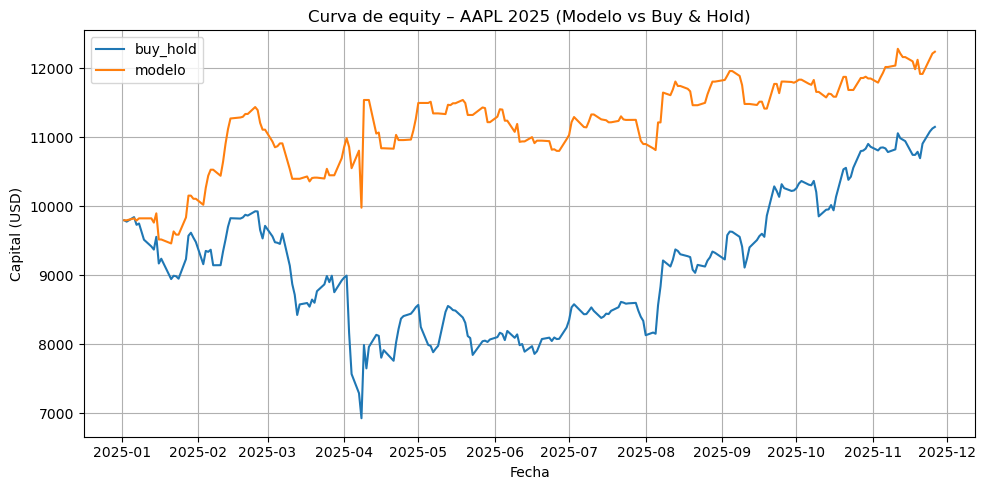

In [8]:
# Celda: curva de equity del modelo vs Buy & Hold

eq_model = sim_model["equity_df"][["date", "capital"]].copy()
eq_model["estrategia"] = "modelo"

eq_bh = sim_bh["equity_df"][["date", "capital"]].copy()
eq_bh["estrategia"] = "buy_hold"

eq_all = pd.concat([eq_model, eq_bh], ignore_index=True)

plt.figure(figsize=(10, 5))
for name, df_plot in eq_all.groupby("estrategia"):
    plt.plot(df_plot["date"], df_plot["capital"], label=name)

plt.title("Curva de equity – AAPL 2025 (Modelo vs Buy & Hold)")
plt.xlabel("Fecha")
plt.ylabel("Capital (USD)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [9]:
# Celda: función genérica para simular cualquier ticker

def run_simulation_for_ticker(
    ticker: str,
    model_filename: str,
    engine,
    capital_inicial: float = 10_000.0,
    start_date: str = "2025-01-01",
    end_date: str = "2025-12-31",
    plot_equity: bool = True,
):
    """
    Carga el modelo serializado, construye features desde analytics.daily_features
    para el ticker dado, filtra año 2025 y corre:

      - Estrategia basada en el modelo (intradía).
      - Baseline Buy & Hold.

    Imprime métricas y, opcionalmente, grafica la curva de equity.
    Devuelve dict con resultados.
    """

    model_path = MODELS_DIR / model_filename
    print(f"\n==============================")
    print(f"=== Simulación para {ticker} ===")
    print(f"Modelo: {model_path}")
    print(f"Rango de simulación: {start_date} → {end_date}")
    print("==============================")

    # 1. Cargar modelo
    model = joblib.load(model_path)
    print("Modelo cargado ✅")

    # 2. Construir features completas para el ticker
    df_model, X_all, y_all, feature_cols = build_features_for_ticker(ticker, engine)

    # 3. Subset 2025
    mask_periodo = (df_model["date"] >= start_date) & (df_model["date"] <= end_date)
    df_periodo = df_model.loc[mask_periodo].copy()
    X_periodo = X_all.loc[mask_periodo].copy()

    print("\nDatos disponibles para el período:")
    print("Filas df_periodo:", len(df_periodo))
    if len(df_periodo) == 0:
        print("⚠️ No hay datos en el rango; abortando simulación.")
        return None

    print("Rango fechas:", df_periodo["date"].min(), "→", df_periodo["date"].max())

    # 4. Predicciones
    y_pred = model.predict(X_periodo)
    unique, counts = np.unique(y_pred, return_counts=True)
    print("\nDistribución de señales:")
    print(dict(zip(unique, counts)))

    # 5. Simulación con modelo
    sim_model = simulate_intraday_strategy(
        df_periodo,
        y_pred,
        capital_inicial=capital_inicial,
    )

    print("\n=== Resultados Estrategia Modelo ===")
    print(f"Capital inicial    : {capital_inicial:,.2f} USD")
    print(f"Capital final      : {sim_model['capital_final']:,.2f} USD")
    print(f"Retorno total      : {sim_model['retorno_total']*100:.2f}%")
    print(f"Retorno anualizado : {sim_model['retorno_anualizado']*100:.2f}%")
    print(f"Número de trades   : {sim_model['n_trades']}")

    # 6. Baseline Buy & Hold
    sim_bh = simulate_buy_and_hold(df_periodo, capital_inicial=capital_inicial)

    print("\n=== Resultados Baseline Buy & Hold ===")
    print(f"Capital inicial    : {capital_inicial:,.2f} USD")
    print(f"Capital final      : {sim_bh['capital_final']:,.2f} USD")
    print(f"Retorno total      : {sim_bh['retorno_total']*100:.2f}%")
    print(f"Retorno anualizado : {sim_bh['retorno_anualizado']*100:.2f}%")
    print(f"Número de trades   : {sim_bh['n_trades']}")

    # 7. Comparación
    print("\n=== Comparación Modelo vs Buy & Hold ===")
    print(f"Modelo  -> {sim_model['capital_final']:,.2f} USD "
          f"({sim_model['retorno_total']*100:.2f}%)")
    print(f"BuyHold -> {sim_bh['capital_final']:,.2f} USD "
          f"({sim_bh['retorno_total']*100:.2f}%)")

    # 8. Curvas de equity (opcional)
    if plot_equity:
        eq_model = sim_model["equity_df"][["date", "capital"]].copy()
        eq_model["estrategia"] = "modelo"

        eq_bh = sim_bh["equity_df"][["date", "capital"]].copy()
        eq_bh["estrategia"] = "buy_hold"

        eq_all = pd.concat([eq_model, eq_bh], ignore_index=True)

        plt.figure(figsize=(10, 5))
        for name, df_plot in eq_all.groupby("estrategia"):
            plt.plot(df_plot["date"], df_plot["capital"], label=name)

        plt.title(f"Curva de equity – {ticker} 2025 (Modelo vs Buy & Hold)")
        plt.xlabel("Fecha")
        plt.ylabel("Capital (USD)")
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # 9. Devolver resultados por si quieres tabular luego
    return {
        "ticker": ticker,
        "sim_model": sim_model,
        "sim_bh": sim_bh,
    }


=== Simulación para AAPL ===
Modelo: models/best_model_AAPL.pkl
Rango de simulación: 2025-01-01 → 2025-12-31
Modelo cargado ✅

=== Construyendo features para AAPL (Simulación) ===
Shape bruto: (1988, 17)
Rango fechas: 2018-01-02 00:00:00 → 2025-11-26 00:00:00
Filas totales: 1988
Filas válidas (con lags): 1977

Datos disponibles para el período:
Filas df_periodo: 227
Rango fechas: 2025-01-02 00:00:00 → 2025-11-26 00:00:00

Distribución de señales:
{0: 59, 1: 168}

=== Resultados Estrategia Modelo ===
Capital inicial    : 10,000.00 USD
Capital final      : 12,239.32 USD
Retorno total      : 22.39%
Retorno anualizado : 22.39%
Número de trades   : 168

=== Resultados Baseline Buy & Hold ===
Capital inicial    : 10,000.00 USD
Capital final      : 11,149.72 USD
Retorno total      : 11.50%
Retorno anualizado : 11.50%
Número de trades   : 1

=== Comparación Modelo vs Buy & Hold ===
Modelo  -> 12,239.32 USD (22.39%)
BuyHold -> 11,149.72 USD (11.50%)


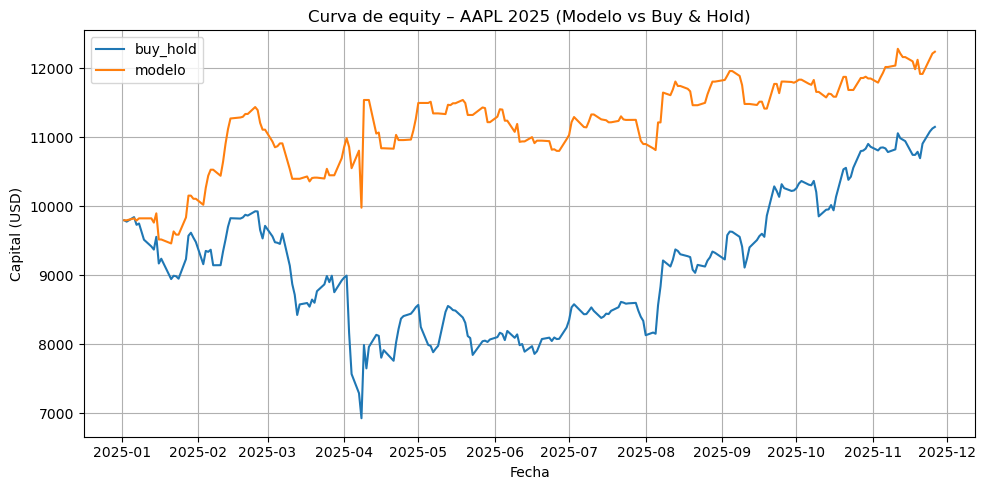


=== Simulación para NKE ===
Modelo: models/best_model_NKE.pkl
Rango de simulación: 2025-01-01 → 2025-12-31
Modelo cargado ✅

=== Construyendo features para NKE (Simulación) ===
Shape bruto: (1988, 17)
Rango fechas: 2018-01-02 00:00:00 → 2025-11-26 00:00:00
Filas totales: 1988
Filas válidas (con lags): 1977

Datos disponibles para el período:
Filas df_periodo: 227
Rango fechas: 2025-01-02 00:00:00 → 2025-11-26 00:00:00

Distribución de señales:
{0: 88, 1: 139}

=== Resultados Estrategia Modelo ===
Capital inicial    : 10,000.00 USD
Capital final      : 10,792.40 USD
Retorno total      : 7.92%
Retorno anualizado : 7.92%
Número de trades   : 139

=== Resultados Baseline Buy & Hold ===
Capital inicial    : 10,000.00 USD
Capital final      : 8,436.72 USD
Retorno total      : -15.63%
Retorno anualizado : -15.63%
Número de trades   : 1

=== Comparación Modelo vs Buy & Hold ===
Modelo  -> 10,792.40 USD (7.92%)
BuyHold -> 8,436.72 USD (-15.63%)


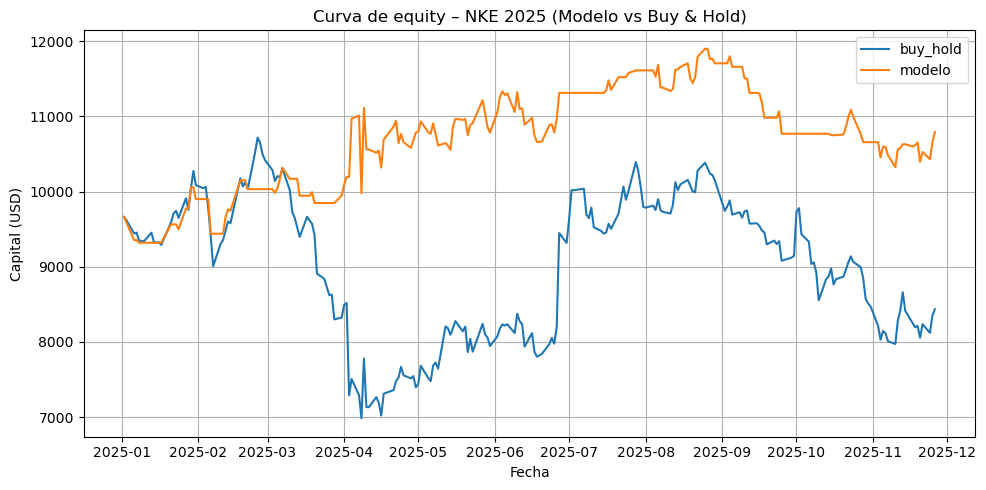

In [12]:
# Celda: ejecutar simulaciones para AAPL, NKE y MBG.DE

results_sim = {}

results_sim["AAPL"] = run_simulation_for_ticker(
    ticker="AAPL",
    model_filename="best_model_AAPL.pkl",
    engine=engine,
    capital_inicial=10_000.0,
)

results_sim["NKE"] = run_simulation_for_ticker(
    ticker="NKE",
    model_filename="best_model_NKE.pkl",
    engine=engine,
    capital_inicial=10_000.0,
)


In [13]:
# Celda opcional: resumen tabular de simulaciones

rows = []
for ticker, res in results_sim.items():
    if res is None:
        continue
    sim_model = res["sim_model"]
    sim_bh = res["sim_bh"]
    rows.append({
        "ticker": ticker,
        "capital_final_model": sim_model["capital_final"],
        "retorno_model": sim_model["retorno_total"],
        "capital_final_bh": sim_bh["capital_final"],
        "retorno_bh": sim_bh["retorno_total"],
        "n_trades_model": sim_model["n_trades"],
    })

df_summary = pd.DataFrame(rows)
df_summary

,ticker,capital_final_model,retorno_model,capital_final_bh,retorno_bh,n_trades_model
0,AAPL,12239.324969,0.223932,11149.720643,0.114972,168
1,NKE,10792.403203,0.079240,8436.721552,-0.156328,139


## Relación entre métricas de ML y desempeño económico

En el notebook de ML (`02_ml_trading_classifier.ipynb`) el modelo ganador para AAPL
(familia ExtraTrees) obtuvo métricas moderadas:

- F1 en validación ≈ 0.66, ligeramente por debajo del baseline (≈ 0.71).
- En Test (2024), F1 ≈ 0.68 y ROC-AUC ≈ 0.49, es decir, muy cercano a 0.5.
- La variable objetivo (`target_up`) está aproximadamente balanceada
  (≈ 54% días alcistas, 46% bajistas).

A primera vista, un ROC-AUC tan cercano a 0.5 sugiere que el modelo no es capaz de
ordenar los días alcistas por probabilidad de forma mucho mejor que el azar. Sin embargo,
en la simulación de trading sobre el año 2025 observamos:

- **Modelo**: retorno ≈ **22.39%** sobre el capital inicial de 10 000 USD.
- **Buy & Hold**: retorno ≈ **11.50%** en el mismo período.

Es decir, el modelo casi duplica el retorno del buy & hold en este año de prueba,
a pesar de tener métricas de clasificación moderadas.

Esto ocurre porque:

1. **Las métricas se calculan sobre direcciones (0/1), no sobre retornos.**  
   El F1 mide qué tan bien acierta la dirección del movimiento, pero no distingue
   entre un día en que el activo sube +0.2% y otro en que sube +3%.  
   Si el modelo tiende a acertar con mayor frecuencia en los días con retornos
   positivos “grandes” y a equivocarse en días con movimientos pequeños, el impacto
   económico puede ser muy favorable aunque el F1 no sea espectacular.

2. **La estrategia sólo actúa cuando el modelo predice 1.**  
   En 2025 el modelo genera 168 señales de compra y se mantiene en efectivo el resto
   del tiempo. Aunque la tasa de acierto global no sea muy superior al azar, es
   posible que los días en los que decide entrar concentren algo más de rentabilidad
   que el promedio del mercado. Esa pequeña “ventaja” se acumula de forma multiplicativa
   a lo largo del año.

3. **El ROC-AUC refleja la calidad del ranking de probabilidades, no de la etiqueta.**  
   El modelo se evalúa en términos de etiquetas binarias (usando un umbral de 0.5
   sobre la probabilidad de subida). Si las probabilidades están mal calibradas o
   son poco diferenciadas, el ROC-AUC puede ser cercano a 0.5 aunque el clasificador
   sea útil como “disparador” de señales binarias.

### Cuando un buen F1 no garantiza un buen PnL

El experimento también ilustra que un F1 alto **no garantiza** buenos resultados
económicos. Algunos escenarios donde esto puede ocurrir son:

- **Asimetría de retornos**: el modelo puede acertar muchos días con movimientos
  pequeños (buen F1), pero equivocarse justo en unos pocos días con caídas muy fuertes,
  generando pérdidas grandes en la curva de capital.

- **Demasiados trades**: si la estrategia abre y cierra posiciones casi todos los días,
  los costos de transacción, spreads y slippage pueden destruir el rendimiento, incluso
  si el F1 es alto en términos de dirección.

- **Cambio de régimen**: el F1 se calcula sobre un período histórico (por ejemplo 2024),
  pero la simulación se realiza en un período posterior (2025). Un cambio de volatilidad,
  tendencias o comportamiento del activo puede hacer que un modelo con muy buen F1
  histórico tenga un desempeño pobre en el nuevo régimen.

- **Métrica mal alineada con el objetivo de negocio**: F1 pondera por igual falsos
  positivos y falsos negativos, mientras que, en trading, un falso positivo (entrar
  en un día muy bajista) puede ser mucho más costoso que un falso negativo
  (no entrar en un día alcista).

Por todo esto, el proyecto combina **métricas de ML** (F1, ROC-AUC, etc.) con
**métricas económicas** (PnL, capital final, número de trades) para evaluar de manera
más completa la utilidad práctica del modelo.